In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

import cv2
import numpy as np

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Handle videos where frame count is 0
    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # 🔴 Important fix
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    return np.array(frames)



def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    frames = preprocess_input(frames)
    predictions = model.predict(frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)
    #top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=1)

    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    for pred in top_pred[0]:
      print(pred[1], ":", round(pred[2]*100, 2), "%")


    print("Final Prediction:", top_pred[0][0][1])

# Replace with your video path
video_path = "/content/026c7465-309f6d33.mp4"
classify_video(video_path)


Extracted frames: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
cab : 17.92 %
traffic_light : 6.14 %
streetcar : 5.89 %
jinrikisha : 3.63 %
limousine : 3.56 %
Final Prediction: cab


In [3]:
pip install transformers torch


In [4]:
import cv2
import numpy as np
import torch
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

# 1. Load Pretrained VideoMAE (Finetuned on Kinetics-400)
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def extract_16_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # VideoMAE usually uses 16 frames sampled across the clip
    indices = np.linspace(0, total_frames - 1, 16, dtype=int)

    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        if len(frames) == 16: break

    cap.release()
    return frames

def classify_with_videomae(video_path):
    # Extract frames
    video_frames = extract_16_frames(video_path)
    if video_frames is None or len(video_frames) < 16:
        print("Error: Could not extract enough frames.")
        return

    # 2. Preprocess: Resizes to 224x224 and normalizes
    inputs = processor(list(video_frames), return_tensors="pt")

    # 3. Forward Pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # 4. Get Results
    # VideoMAE outputs 400 action classes (e.g., 'driving car', 'walking')
    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_results = torch.topk(probs, 5)

    print(f"--- Top 5 Predictions for: {video_path.split('/')[-1]} ---")
    for i in range(5):
        score = top_results.values[0][i].item()
        label_id = top_results.indices[0][i].item()
        label = model.config.id2label[label_id]
        print(f"{label}: {round(score * 100, 2)}%")

# Usage
video_path = "/content/026c7465-309f6d33.mp4"
classify_with_videomae(video_path)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

--- Top 5 Predictions for: 026c7465-309f6d33.mp4 ---
pushing car: 17.94%
driving car: 14.6%
pushing cart: 9.87%
pushing wheelchair: 3.61%
motorcycling: 2.41%


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

Visualising extracted frames...


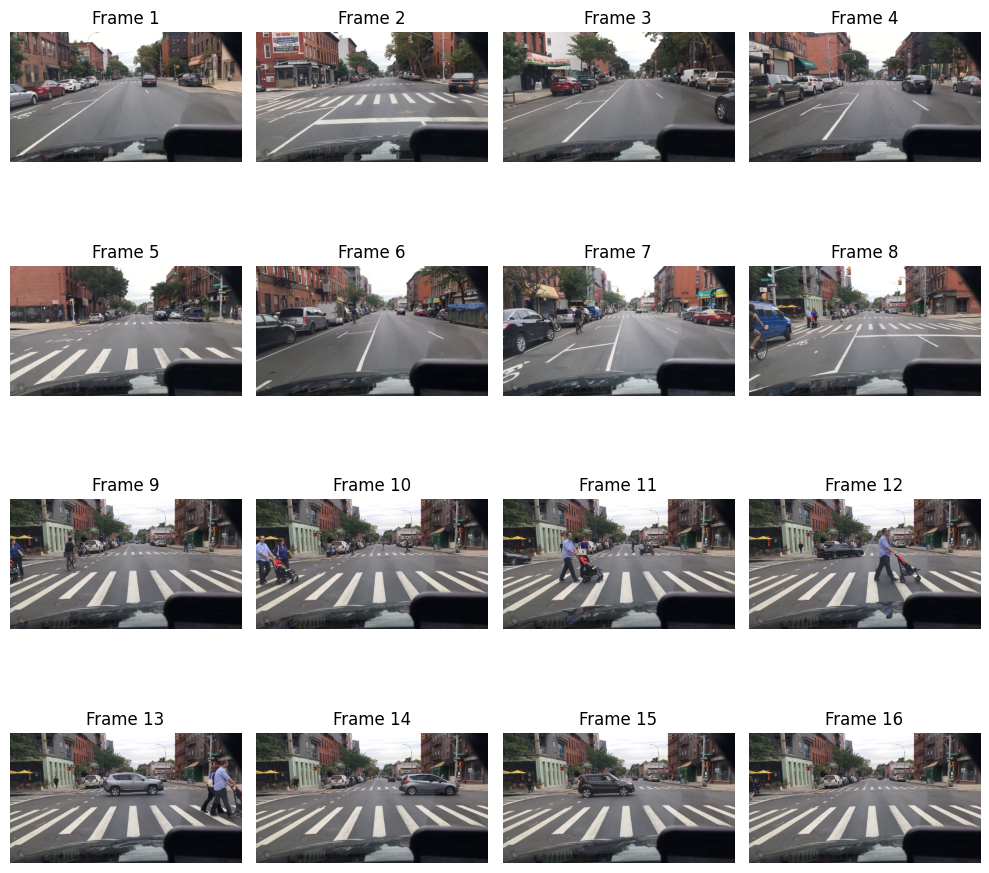


--- Top 5 Predictions for: 026c7465-309f6d33.mp4 ---
pushing car: 17.94%
driving car: 14.6%
pushing cart: 9.87%
pushing wheelchair: 3.61%
motorcycling: 2.41%


In [5]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

# 1. Load Pretrained VideoMAE
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def extract_16_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, 16, dtype=int)

    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        if len(frames) == 16: break
    cap.release()
    return frames

def display_frames(frames):
    """Plots the 16 extracted frames in a 4x4 grid."""
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(frames[i])
        ax.set_title(f"Frame {i+1}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def classify_with_videomae(video_path):
    video_frames = extract_16_frames(video_path)
    if video_frames is None or len(video_frames) < 16:
        print("Error: Could not extract enough frames.")
        return

    # Visualise extracted frames
    print("Visualising extracted frames...")
    display_frames(video_frames)

    # 2. Preprocess and Predict
    inputs = processor(list(video_frames), return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_results = torch.topk(probs, 5)

    print(f"\n--- Top 5 Predictions for: {video_path.split('/')[-1]} ---")
    for i in range(5):
        score = top_results.values[0][i].item()
        label_id = top_results.indices[0][i].item()
        label = model.config.id2label[label_id]
        print(f"{label}: {round(score * 100, 2)}%")

video_path = "/content/026c7465-309f6d33.mp4"
classify_with_videomae(video_path)


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

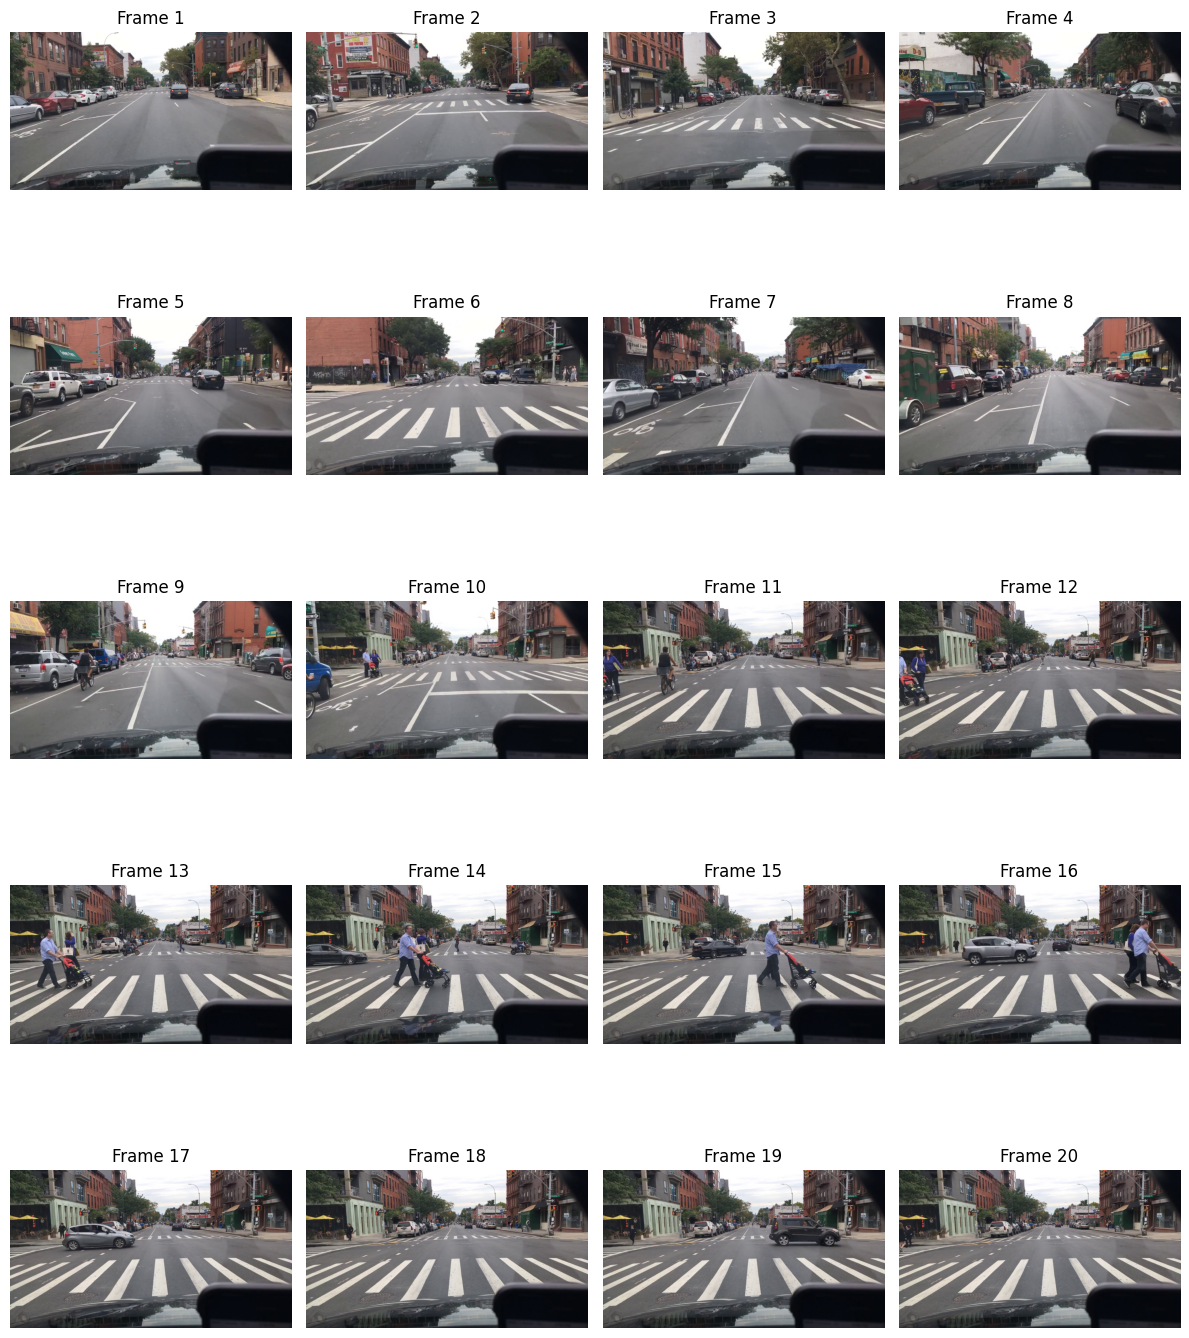


--- Top 5 Predictions (Using 20-frame context) ---
pushing car: 18.87%
driving car: 17.09%
pushing cart: 5.15%
motorcycling: 3.08%
pushing wheelchair: 2.47%


In [7]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

# 1. Load Pretrained VideoMAE
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def extract_20_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Step 1: Extract 20 frames evenly from the video
    indices = np.linspace(0, total_frames - 1, 20, dtype=int)

    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        if len(frames) == 20: break
    cap.release()
    return frames

def display_frames(frames):
    """Plots all 20 extracted frames in a 5x4 grid."""
    fig, axes = plt.subplots(5, 4, figsize=(12, 15))
    for i, ax in enumerate(axes.flat):
        if i < len(frames):
            ax.imshow(frames[i])
            ax.set_title(f"Frame {i+1}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def classify_with_videomae(video_path):
    # Get your 20 frames
    video_frames_20 = extract_20_frames(video_path)
    if not video_frames_20 or len(video_frames_20) < 20:
        print("Error: Could not extract 20 frames.")
        return

    # Visualise the 20 frames
    display_frames(video_frames_20)

    # Step 2: Select 16 frames from the 20 to satisfy the model's requirements
    # This takes 16 evenly spaced frames from your 20-frame list
    selection_indices = np.linspace(0, len(video_frames_20) - 1, 16, dtype=int)
    video_frames_16 = [video_frames_20[i] for i in selection_indices]

    # Step 3: Preprocess and Predict
    inputs = processor(list(video_frames_16), return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_results = torch.topk(probs, 5)

    print(f"\n--- Top 5 Predictions (Using 20-frame context) ---")
    for i in range(5):
        score = top_results.values[0][i].item()
        label_id = top_results.indices[0][i].item()
        label = model.config.id2label[label_id]
        print(f"{label}: {round(score * 100, 2)}%")

# Usage
video_path = "/content/026c7465-309f6d33.mp4"
classify_with_videomae(video_path)


In [8]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

# 1. Load Pretrained VideoMAE
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def extract_20_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, 20, dtype=int)
    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        if len(frames) == 20: break
    cap.release()
    return frames

def classify_with_videomae(video_path):
    video_frames_20 = extract_20_frames(video_path)
    if not video_frames_20 or len(video_frames_20) < 20: return

    # --- NEW: SHOW FRAME COUNT AND PIXEL VALUES ---
    print(f"✅ Total frames extracted: {len(video_frames_20)}")

    # Get shape of the first frame (Height, Width, Channels)
    h, w, c = video_frames_20[0].shape
    print(f"✅ Frame Resolution: {w}x{h} pixels")

    # Show sample pixel values from the center of the first frame
    sample_pixel = video_frames_20[0][h//2, w//2]
    print(f"✅ Sample Pixel Value at center (RGB): {sample_pixel}")
    # ----------------------------------------------

    # Select 16 frames for model
    selection_indices = np.linspace(0, len(video_frames_20) - 1, 16, dtype=int)
    video_frames_16 = [video_frames_20[i] for i in selection_indices]

    # Preprocess
    inputs = processor(list(video_frames_16), return_tensors="pt")

    print(f"✅ Input Tensor Shape: {inputs['pixel_values'].shape} (Batch, Frames, Channels, Height, Width)")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_results = torch.topk(probs, 5)

    print(f"\n--- Top 5 Predictions ---")
    for i in range(5):
        score = top_results.values[0][i].item()
        label_id = top_results.indices[0][i].item()
        label = model.config.id2label[label_id]
        print(f"{label}: {round(score * 100, 2)}%")

# Usage
video_path = "/content/026c7465-309f6d33.mp4"
classify_with_videomae(video_path)


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

✅ Total frames extracted: 20
✅ Frame Resolution: 1280x720 pixels
✅ Sample Pixel Value at center (RGB): [149 148 151]
✅ Input Tensor Shape: torch.Size([1, 16, 3, 224, 224]) (Batch, Frames, Channels, Height, Width)

--- Top 5 Predictions ---
pushing car: 18.87%
driving car: 17.09%
pushing cart: 5.15%
motorcycling: 3.08%
pushing wheelchair: 2.47%


In [9]:
import cv2
import numpy as np
import torch
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

# 1. Load Pretrained VideoMAE
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def extract_20_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, 20, dtype=int)
    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        if len(frames) == 20: break
    cap.release()
    return frames

def classify_with_videomae(video_path):
    video_frames_20 = extract_20_frames(video_path)
    if not video_frames_20 or len(video_frames_20) < 20: return

    print(f"--- RAW PIXEL DATA FOR ALL {len(video_frames_20)} FRAMES ---")

    for i, frame in enumerate(video_frames_20):
        print(f"\nFRAME {i+1} (Shape: {frame.shape})")
        # Printing the array shows the raw RGB values (0-255)
        # NumPy automatically truncates the middle to keep it readable
        print(frame)

        # Optional: Print the average pixel intensity of the frame
        print(f"Average Pixel Intensity: {np.mean(frame):.2f}")

    # --- MODEL PREDICTION LOGIC ---
    selection_indices = np.linspace(0, len(video_frames_20) - 1, 16, dtype=int)
    video_frames_16 = [video_frames_20[idx] for idx in selection_indices]

    inputs = processor(list(video_frames_16), return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_results = torch.topk(probs, 5)

    print(f"\n--- Top 5 Predictions ---")
    for i in range(5):
        score = top_results.values[0][i].item()
        label_id = top_results.indices[0][i].item()
        label = model.config.id2label[label_id]
        print(f"{label}: {round(score * 100, 2)}%")

# Usage
video_path = "/content/026c7465-309f6d33.mp4"
classify_with_videomae(video_path)


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

--- RAW PIXEL DATA FOR ALL 20 FRAMES ---

FRAME 1 (Shape: (720, 1280, 3))
[[[ 61  67  54]
  [ 61  67  54]
  [ 61  67  54]
  ...
  [  8  13  19]
  [  8  13  19]
  [  8  13  19]]

 [[ 61  67  54]
  [ 61  67  54]
  [ 61  67  54]
  ...
  [  8  13  19]
  [  8  13  19]
  [  8  13  19]]

 [[ 58  64  51]
  [ 58  64  51]
  [ 58  64  51]
  ...
  [  8  13  19]
  [  8  13  19]
  [  8  13  19]]

 ...

 [[123 122 127]
  [122 121 126]
  [121 120 125]
  ...
  [ 34  33  38]
  [ 34  33  38]
  [ 34  33  38]]

 [[124 123 128]
  [121 120 125]
  [115 114 119]
  ...
  [ 36  35  40]
  [ 36  35  40]
  [ 36  35  40]]

 [[112 111 116]
  [108 107 112]
  [100  99 104]
  ...
  [ 36  35  40]
  [ 36  35  40]
  [ 36  35  40]]]
Average Pixel Intensity: 106.21

FRAME 2 (Shape: (720, 1280, 3))
[[[129  69  67]
  [129  69  67]
  [129  69  67]
  ...
  [ 11  14  21]
  [ 11  14  21]
  [ 11  14  21]]

 [[126  66  64]
  [126  66  64]
  [126  66  64]
  ...
  [ 11  14  21]
  [ 11  14  21]
  [ 11  14  21]]

 [[126  66  64]
  [126 